In [1]:
import os
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import csv
import shutil
import seaborn as sns
from collections import defaultdict
from sklearn.metrics.pairwise import cosine_similarity
from statsmodels.stats.anova import AnovaRM
from statsmodels.stats.multitest import fdrcorrection
import matplotlib.cm as cm
import re
import pingouin as pg
from scipy.stats import sem
import statsmodels.formula.api as smf

from pathlib import Path

def find_project_root(start=None):
    p = Path(os.environ.get('MAZE_PROJECT_ROOT') or start or Path.cwd()).resolve()
    for cand in [p, *p.parents]:
        if (cand / '_DATA').is_dir() and (cand / 'Mazes').is_dir():
            return cand
    raise RuntimeError(
        f'Could not locate the project root (a folder holding _DATA/ and Mazes/) '
        f'from {p}. Set MAZE_PROJECT_ROOT to the repository root.')

project_path = str(find_project_root())
os.chdir(project_path)

home_path  = os.path.expanduser('~')
data_path  = os.path.join(project_path, '_DATA')
maze_dir   = os.path.join(project_path, 'Mazes')
figure_path = os.path.join(project_path, 'figures')
os.makedirs(figure_path, exist_ok=True)

print(project_path)
print(data_path)

/Users/minjaejo/Desktop/2025_Maze_Behavior
/Users/minjaejo/Desktop/2025_Maze_Behavior/_DATA


### Group 1

In [ ]:
exclude_subs = []

file_types = ['EgoEgo', 'AlloEgo']
stats_list = []
collapsed_list = pd.DataFrame()
egoego_list = pd.DataFrame()
alloego_list = pd.DataFrame()

for i, file_type in enumerate(file_types):

    subject_dirs = [os.path.join(data_path, d) for d in os.listdir(data_path)
                    if os.path.isdir(os.path.join(data_path, d)) and d.startswith('Sub-')]
    subject_dirs = [d for d in subject_dirs if not any(sub in d for sub in exclude_subs)]

    frames = []
    for dir in subject_dirs:
        fp = os.path.join(dir, f"{os.path.basename(dir).lower()}_{file_type}.csv")
        if os.path.exists(fp):
            df = pd.read_csv(fp)
            subject_id = int(os.path.basename(dir).split('-')[1])
            df['subject_id'] = subject_id
            frames.append(df)

    all_data = pd.concat(frames, ignore_index=True)
    # here we will calculate task completion time for each trial, each subject, for each phaseview
    all_data['Time'] = pd.to_numeric(all_data['Time'], errors='coerce')
    
    durations = (
    all_data.sort_values(['subject_id', 'PhaseView', 'Trial', 'Time'])
            .groupby(['subject_id', 'PhaseView', 'Trial'])['Time']
            .agg(start_time='min', end_time='max')
            .reset_index()
    )
    
    durations['duration'] = np.round(durations['end_time'] - durations['start_time'], 5)
    
    # trial mapping 1~12
    durations['TrialMap'] = durations.groupby(['subject_id', 'PhaseView']).cumcount() + 1
    # 1~12 -> 1~6으로 fold
    durations['Trial6'] = ((durations['TrialMap'] - 1) % 6) + 1
    durations = durations[['subject_id', 'PhaseView', 'Trial', 'TrialMap', 'Trial6', 'duration']]
    # average for trialmapped version of durations
    durations_all = (
    durations.groupby(['subject_id', 'PhaseView', 'Trial6'])['duration']
      .agg(duration_avg='mean')
      .reset_index()
    )
    durations_all['duration_avg'] = durations_all['duration_avg'].round(5)
    collapsed_list = pd.concat([collapsed_list, durations_all], ignore_index=True)
    if file_type == 'EgoEgo':
        egoego_list = pd.concat([egoego_list, durations_all], ignore_index=True)
    elif file_type == 'AlloEgo':
        alloego_list = pd.concat([alloego_list, durations_all], ignore_index=True)
    # Mean & sem
    stats_phase_trial = (
      durations_all.groupby(['PhaseView', 'Trial6'])['duration_avg']
      .agg(['mean', sem])
      .reset_index()
    )
    stats_phase_trial['Condition'] = file_type
    stats_phase_trial.to_csv(f"BEH_01_{file_type}_stats.csv", index=False)
    stats_list.append(stats_phase_trial)

### Group 2

In [ ]:
exclude_subs = []

file_types = ['AlloAllo', 'EgoAllo']
stats_list = []
collapsed_list = pd.DataFrame()
alloallo_list = pd.DataFrame()
egoallo_list = pd.DataFrame()

for i, file_type in enumerate(file_types):

    subject_dirs = [os.path.join(data_path, d) for d in os.listdir(data_path)
                    if os.path.isdir(os.path.join(data_path, d)) and d.startswith('Sub-')]
    subject_dirs = [d for d in subject_dirs if not any(sub in d for sub in exclude_subs)]

    frames = []
    for dir in subject_dirs:
        fp = os.path.join(dir, f"{os.path.basename(dir).lower()}_{file_type}.csv")
        if os.path.exists(fp):
            df = pd.read_csv(fp)
            subject_id = int(os.path.basename(dir).split('-')[1])
            df['subject_id'] = subject_id
            frames.append(df)

    all_data = pd.concat(frames, ignore_index=True)
    # here we will calculate task completion time for each trial, each subject, for each phaseview
    all_data['Time'] = pd.to_numeric(all_data['Time'], errors='coerce')
    
    durations = (
    all_data.sort_values(['subject_id', 'PhaseView', 'Trial', 'Time'])
            .groupby(['subject_id', 'PhaseView', 'Trial'])['Time']
            .agg(start_time='min', end_time='max')
            .reset_index()
    )
    
    durations['duration'] = np.round(durations['end_time'] - durations['start_time'], 5)
    
    # trial mapping 1~12
    durations['TrialMap'] = durations.groupby(['subject_id', 'PhaseView']).cumcount() + 1
    # 1~12 -> 1~6으로 fold
    durations['Trial6'] = ((durations['TrialMap'] - 1) % 6) + 1
    durations = durations[['subject_id', 'PhaseView', 'Trial', 'TrialMap', 'Trial6', 'duration']]
    # average for trialmapped version of durations
    durations_all = (
    durations.groupby(['subject_id', 'PhaseView', 'Trial6'])['duration']
      .agg(duration_avg='mean')
      .reset_index()
    )
    durations_all['duration_avg'] = durations_all['duration_avg'].round(5)
    collapsed_list = pd.concat([collapsed_list, durations_all], ignore_index=True)
    if file_type == 'AlloAllo':
        alloallo_list = pd.concat([alloallo_list, durations_all], ignore_index=True)
    elif file_type == 'EgoAllo':
        egoallo_list = pd.concat([egoallo_list, durations_all], ignore_index=True)
    # Mean & sem
    stats_phase_trial = (
      durations_all.groupby(['PhaseView', 'Trial6'])['duration_avg']
      .agg(['mean', sem])
      .reset_index()
    )
    stats_phase_trial['Condition'] = file_type
    stats_phase_trial.to_csv(f"BEH_01_{file_type}_stats.csv", index=False)
    stats_list.append(stats_phase_trial)

### Change RT to log scale

LME — EgoEgo Test
          Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: log_duration
No. Observations: 120     Method:             REML        
No. Groups:       20      Scale:              0.0426      
Min. group size:  6       Log-Likelihood:     -14.7769    
Max. group size:  6       Converged:          Yes         
Mean group size:  6.0                                     
----------------------------------------------------------
                Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------
Intercept        4.800    0.092 52.275 0.000  4.620  4.979
Trial6          -0.072    0.011 -6.491 0.000 -0.093 -0.050
subject_id Var   0.132    0.238                           


LME — AlloEgo Test
          Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: log_duration
No. Observations: 120     Method:             REML        
No. Groups:       20      Scale:       

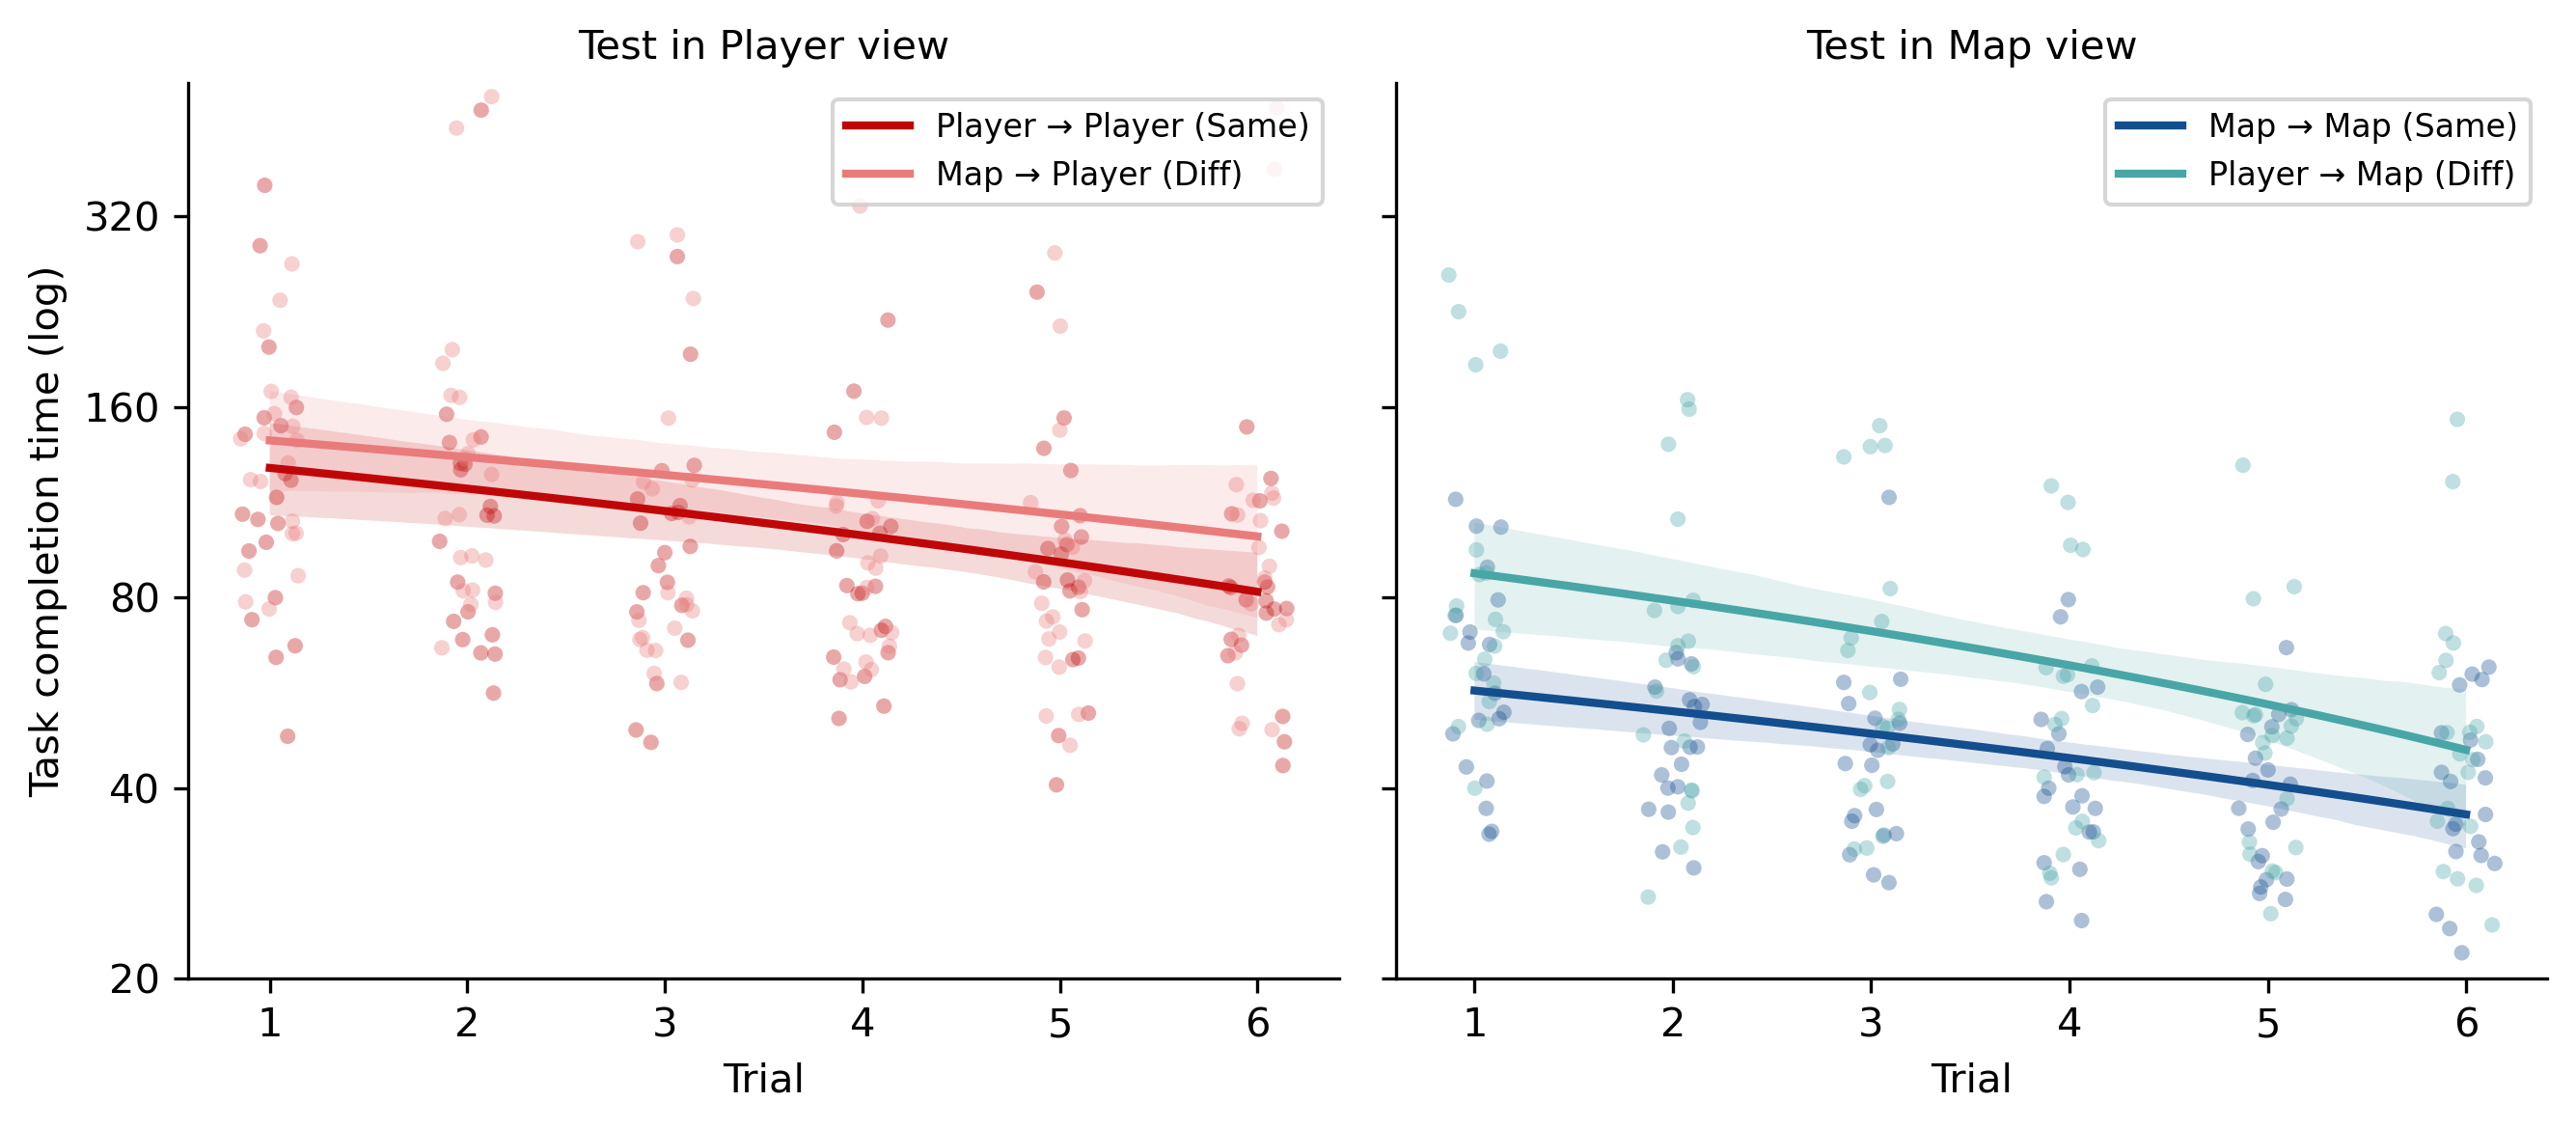

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from matplotlib.ticker import FixedLocator, ScalarFormatter

# ── Shared layout params (match with same-only plot) ──
FIGSIZE = (9, 4)
DPI     = 300
Y_MIN, Y_MAX = 20, 520
YTICKS  = [20, 40, 80, 160, 320]

# ── Data: four test conditions ──
ee_test = egoego_list[egoego_list['PhaseView'] == 2].reset_index(drop=True)
ee_test['log_duration'] = np.log(ee_test['duration_avg'])
ee_test['condition'] = 'EgoEgo'

ae_test = alloego_list[alloego_list['PhaseView'] == 2].reset_index(drop=True)
ae_test['log_duration'] = np.log(ae_test['duration_avg'])
ae_test['condition'] = 'AlloEgo'

aa_test = alloallo_list[alloallo_list['PhaseView'] == 3].reset_index(drop=True)
aa_test['log_duration'] = np.log(aa_test['duration_avg'])
aa_test['condition'] = 'AlloAllo'

ea_test = egoallo_list[egoallo_list['PhaseView'] == 3].reset_index(drop=True)
ea_test['log_duration'] = np.log(ea_test['duration_avg'])
ea_test['condition'] = 'EgoAllo'

all_test = pd.concat([ee_test, ae_test, aa_test, ea_test], ignore_index=True)

# ── LME per condition ──
for cond in ['EgoEgo', 'AlloEgo', 'AlloAllo', 'EgoAllo']:
    sub = all_test[all_test['condition'] == cond]
    m = smf.mixedlm("log_duration ~ Trial6", data=sub,
                     groups="subject_id", re_formula="~1").fit()
    print("=" * 60)
    print(f"LME — {cond} Test")
    print("=" * 60)
    print(m.summary())
    print()

# ── Plot: 1x2, left = Ego test (red), right = Allo test (blue) ──
fig, axes = plt.subplots(1, 2, figsize=FIGSIZE, dpi=DPI, sharey=True)
rng = np.random.default_rng(0)

panel_specs = [
    (axes[0], 'Test in Player view', [
        ('EgoEgo',  'Player → Player (Same)', '#C00707'),
        ('AlloEgo', 'Map → Player (Diff)',    '#EA7B7B'),
    ]),
    (axes[1], 'Test in Map view', [
        ('AlloAllo', 'Map → Map (Same)',      '#134E8E'),
        ('EgoAllo',  'Player → Map (Diff)',   '#48A6A7'),
    ]),
]

for ax, title, cond_list in panel_specs:
    for cond, label, color in cond_list:
        df = all_test[all_test['condition'] == cond]
        jitter = rng.uniform(-0.15, 0.15, size=len(df))
        ax.scatter(df['Trial6'] + jitter, df['duration_avg'],
                   color=color, alpha=0.35, s=15, edgecolors='none')
        sns.regplot(data=df, x='Trial6', y='duration_avg',
                    scatter=False, ci=95, ax=ax, color=color,
                    line_kws={'lw': 2}, label=label)

    ax.set_yscale('log')
    ax.set_ylim(Y_MIN, Y_MAX)
    ax.yaxis.set_major_locator(FixedLocator(YTICKS))
    ax.yaxis.set_major_formatter(ScalarFormatter())
    ax.yaxis.set_minor_formatter(plt.NullFormatter())
    ax.tick_params(axis='y', which='minor', length=0)
    ax.set_xlabel('Trial')
    ax.set_xticks([1, 2, 3, 4, 5, 6])
    ax.set_title(title, fontsize=10)
    ax.legend(frameon=True, fontsize=8, loc='upper right')
    sns.despine(ax=ax)

axes[0].set_ylabel('Task completion time (log)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig(os.path.join(project_path, 'figures/BEH_01_CompletionTime_AllTest_log.pdf'),
            bbox_inches='tight')
plt.show()